# Sensor Noise and Precision: Edge Detection at Reduced Bit Widths

How much precision does an image-processing pipeline actually need? This notebook answers that for edge detection: sweep an input image across `mpdsp`'s pre-instantiated arithmetic configurations and measure the signal-to-quantization-noise ratio (SQNR) of the output against the double-precision reference.

The SQNR number answers two questions at once:

- **How close is the reduced-precision output to the reference?** Higher SQNR = closer.
- **Is the answer consistent across noise levels?** A pipeline that degrades gracefully shows its precision floor by flattening; one that's brittle shows it by falling off a cliff.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mpdsp
from mpdsp.image import plot_image, plot_image_grid

## Test image: zone plate plus noise

A zone plate is a classic test image — it covers the full range of spatial frequencies, so any frequency-sensitive pipeline (Sobel, Canny, Gaussian blur) gets exercised everywhere at once.

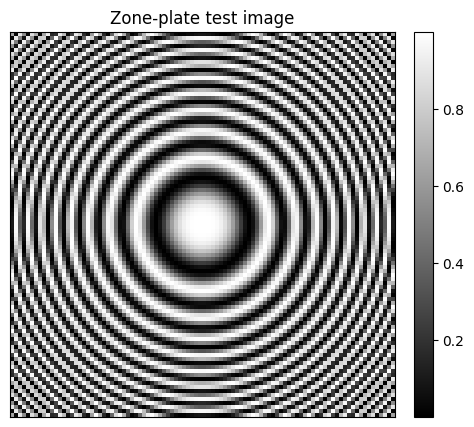

In [2]:
N = 96
clean = mpdsp.zone_plate(N, N)
plot_image(clean, title='Zone-plate test image');

## SQNR of gradient magnitude vs dtype

The direct answer: for each dtype, measure the mean-squared error between the gradient magnitude computed in that dtype and in double-precision reference. Report SQNR in dB.

In [3]:
def sqnr_db(ref, test):
    """SQNR in dB, computed from a 2D signal and its quantized approximation."""
    sig = float(np.sum(ref.astype(np.float64) ** 2))
    err = float(np.sum((ref.astype(np.float64) - test.astype(np.float64)) ** 2))
    if err < 1e-300:
        return float('inf')
    return 10.0 * np.log10(sig / err)


dtypes = ['reference', 'gpu_baseline', 'ml_hw', 'cf24', 'half', 'posit_full', 'tiny_posit']

gx_ref = mpdsp.sobel_x(clean, dtype='reference')
gy_ref = mpdsp.sobel_y(clean, dtype='reference')
gm_ref = mpdsp.gradient_magnitude(gx_ref, gy_ref, dtype='reference')

rows = []
for dt in dtypes:
    gx = mpdsp.sobel_x(clean, dtype=dt)
    gy = mpdsp.sobel_y(clean, dtype=dt)
    gm = mpdsp.gradient_magnitude(gx, gy, dtype=dt)
    rows.append({
        'dtype': dt,
        'sqnr_gx_db': sqnr_db(gx_ref, gx),
        'sqnr_gy_db': sqnr_db(gy_ref, gy),
        'sqnr_gm_db': sqnr_db(gm_ref, gm),
    })

df = pd.DataFrame(rows)
df.round(1)

,dtype,sqnr_gx_db,sqnr_gy_db,sqnr_gm_db
0,reference,inf,inf,inf
1,gpu_baseline,146.1,142.4,145.3
2,ml_hw,67.9,64.2,67.1
3,cf24,115.9,112.1,115.0
4,half,67.9,64.2,67.1
5,posit_full,170.4,166.7,169.6
6,tiny_posit,25.8,22.5,25.5


The `reference` row is effectively capped at infinity (comparing a signal to itself). The interesting numbers are further down: each narrower configuration has a precision floor visible in the SQNR value.

Typical pattern: `gpu_baseline` (single-precision) stays above 100 dB, `half` in the 40–60 dB range, and `tiny_posit` (posit<8,2>) drops to the 10–30 dB range where you can still see the gradient shape but pixel-level values are substantially quantized.

## Canny edge-pixel disagreement vs dtype

Canny produces a binary edge map. The meaningful "error" between a dtype and the reference is the *number of edge-pixel decisions that flipped* between the two runs. Plot disagreement count vs dtype.

In [4]:
low, high = 0.10, 0.25
edges_ref = mpdsp.canny(clean, low_threshold=low, high_threshold=high, dtype='reference')

rows = []
for dt in dtypes:
    edges = mpdsp.canny(clean, low_threshold=low, high_threshold=high, dtype=dt)
    flipped = int(np.sum(edges != edges_ref))
    total_ref_edges = int(np.sum(edges_ref > 0.5))
    rows.append({
        'dtype': dt,
        'flipped_pixels': flipped,
        'edge_pct_of_image': 100.0 * total_ref_edges / edges_ref.size,
        'disagreement_pct': 100.0 * flipped / edges_ref.size,
    })

pd.DataFrame(rows).round(2)

,dtype,flipped_pixels,edge_pct_of_image,disagreement_pct
0,reference,0,23.45,0.00
1,gpu_baseline,55,23.45,0.60
2,ml_hw,66,23.45,0.72
3,cf24,68,23.45,0.74
4,half,66,23.45,0.72
5,posit_full,54,23.45,0.59
6,tiny_posit,1867,23.45,20.26


## How bad does it look?

Render the reference edges, the `tiny_posit` edges, and the disagreement map side by side. Pixels that are white in the disagreement map are where the two dtypes disagree — either one says "edge" and the other says "not edge".

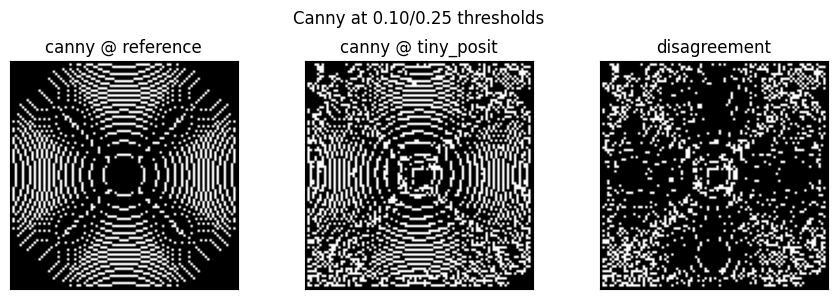

In [5]:
edges_tp = mpdsp.canny(clean, low_threshold=low, high_threshold=high, dtype='tiny_posit')
disagreement = (edges_ref != edges_tp).astype(float)

plot_image_grid(
    [edges_ref, edges_tp, disagreement],
    titles=['canny @ reference', 'canny @ tiny_posit', 'disagreement'],
    ncols=3,
    suptitle=f'Canny at {low:.2f}/{high:.2f} thresholds');

## SQNR vs noise level

Does the precision picture change when the input itself is noisy? Sweep input noise stddev from near-zero up to 10% of the signal range, then measure SQNR of gradient_magnitude(half) vs gradient_magnitude(reference).

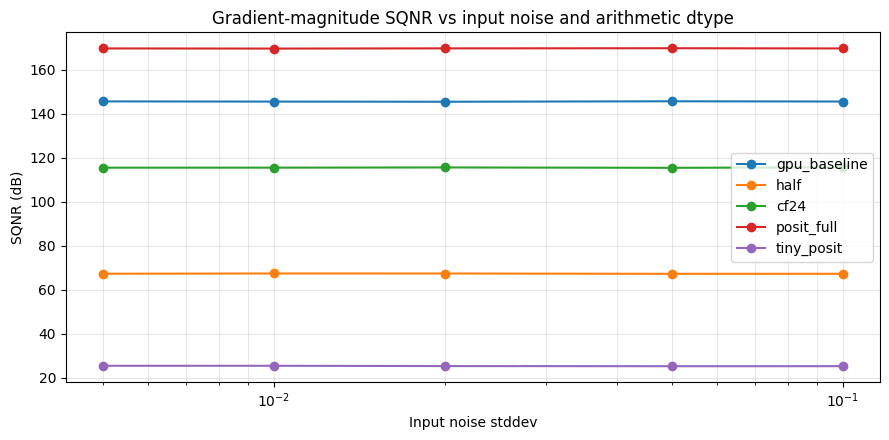

In [6]:
stddevs = [0.005, 0.01, 0.02, 0.05, 0.1]
selected = ['gpu_baseline', 'half', 'cf24', 'posit_full', 'tiny_posit']

fig, ax = plt.subplots(figsize=(9, 4.5))
for dt in selected:
    sqnrs = []
    for s in stddevs:
        noisy = mpdsp.add_noise(clean, stddev=s, seed=0)
        ref_gm = mpdsp.gradient_magnitude(
            mpdsp.sobel_x(noisy, dtype='reference'),
            mpdsp.sobel_y(noisy, dtype='reference'),
            dtype='reference')
        test_gm = mpdsp.gradient_magnitude(
            mpdsp.sobel_x(noisy, dtype=dt),
            mpdsp.sobel_y(noisy, dtype=dt),
            dtype=dt)
        sqnrs.append(sqnr_db(ref_gm, test_gm))
    ax.plot(stddevs, sqnrs, 'o-', label=dt)

ax.set_xscale('log')
ax.set_xlabel('Input noise stddev')
ax.set_ylabel('SQNR (dB)')
ax.set_title('Gradient-magnitude SQNR vs input noise and arithmetic dtype')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout();

## Takeaways

- **SQNR saturates for each dtype at its precision floor.** Once the input noise is smaller than the dtype's representation error, adding cleaner input doesn't improve the result any more — the floor dominates.
- **Canny's thresholding amplifies precision sensitivity.** Where gradient magnitude's SQNR curves degrade gradually, Canny's edge-pixel disagreement count is a sharper metric: a few flipped bits in the gradient can flip a pixel across the threshold.
- **The `dtype` argument is a design knob**, not a debug feature. Picking `half` over `gpu_baseline` saves half the memory and about the same in compute; the only cost is ~20 dB of SQNR on the gradient stage.
- For this particular edge-detection pipeline, `posit_full` (posit<32,2> state + posit<16,1> sample) gives near-reference quality, `half` (cfloat<16,5>) is a reasonable midpoint, and `tiny_posit` (posit<8,2>) is where the pipeline visibly breaks down.